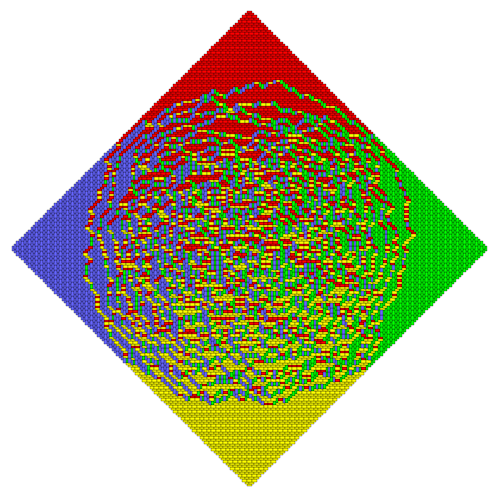

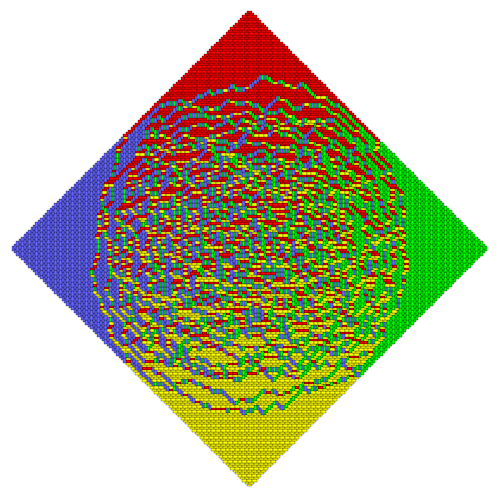

In [ ]:
import numpy as np
from RandomTilingsV1.draw_aztec import draw_aztec

import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk


class CustomToolbar(NavigationToolbar2Tk):
    # Remove the "Configure subplots" button
    toolitems = [
        item for item in NavigationToolbar2Tk.toolitems
        if item[0] != "Subplots"
    ]


def compute_figure():
    n = 100
    w = np.array([[1]])
    fig = draw_aztec(n, w, show_figure=False, dpi=100,edge=20/n)
    return fig


def add_scroll_zoom(canvas, ax):
    def on_scroll(event):
        if event.inaxes != ax:
            return

        base_scale = 1.2

        if event.button == "up":
            scale_factor = 1 / base_scale
        elif event.button == "down":
            scale_factor = base_scale
        else:
            return

        xdata, ydata = event.xdata, event.ydata
        if xdata is None or ydata is None:
            return

        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        new_width = (xlim[1] - xlim[0]) * scale_factor
        new_height = (ylim[1] - ylim[0]) * scale_factor

        relx = (xlim[1] - xdata) / (xlim[1] - xlim[0])
        rely = (ylim[1] - ydata) / (ylim[1] - ylim[0])

        ax.set_xlim([
            xdata - new_width * (1 - relx),
            xdata + new_width * relx
        ])
        ax.set_ylim([
            ydata - new_height * (1 - rely),
            ydata + new_height * rely
        ])

        canvas.draw_idle()

    canvas.mpl_connect("scroll_event", on_scroll)


root = tk.Tk()
root.title("Aztec plot viewer")
root.geometry("900x700")

top_frame = tk.Frame(root)
top_frame.pack(side=tk.TOP, fill=tk.X)

plot_frame = tk.Frame(root)
plot_frame.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

current_canvas = None
current_toolbar = None


def show_figure_in_main_window(fig):
    global current_canvas, current_toolbar

    # Remove old plot/toolbar if button is clicked again
    if current_canvas is not None:
        current_canvas.get_tk_widget().destroy()
        current_canvas = None

    if current_toolbar is not None:
        current_toolbar.destroy()
        current_toolbar = None

    current_canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    current_canvas.draw()

    current_toolbar = CustomToolbar(current_canvas, plot_frame)
    current_toolbar.update()

    # Activate pan/move mode by default
    current_toolbar.pan()

    current_toolbar.pack(side=tk.TOP, fill=tk.X)
    current_canvas.get_tk_widget().pack(side=tk.TOP, fill=tk.BOTH, expand=True)

    for ax in fig.axes:
        add_scroll_zoom(current_canvas, ax)


def on_click():
    fig = compute_figure()
    show_figure_in_main_window(fig)


button = tk.Button(top_frame, text="Show plot", command=on_click)
button.pack(side=tk.LEFT, padx=5, pady=5)

root.mainloop()